# Drug Review Sentiment Analysis — Data Cleaning & Preprocessing

## Overview
This notebook covers the cleaning and preprocessing of the combined 
drug review dataset in preparation for sentiment modelling in Phase 3.

Based on the findings from Phase 1 EDA, the following preprocessing 
steps will be carried out:

1. Drop unnecessary columns
2. Handle missing values and malformed entries in the condition column
3. Decode HTML entities in the review text
4. Remove reviews under 5 words
5. Remove numeric dosage references and special characters
6. Convert the date column to datetime format
7. Create sentiment labels from the numeric rating column
8. Save the cleaned dataset for use in Phase 3

## Input
- drugsComTrain_raw.csv
- drugsComTest_raw.csv (combined in Phase 1)

## Output
- df_clean.csv — cleaned and labelled dataset ready for modelling

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import html
import warnings

warnings.filterwarnings("ignore")

In [13]:
df_train = pd.read_csv('data/drugsComTrain_raw.csv')
df_test = pd.read_csv('data/drugsComTest_raw.csv')

df_train['split'] = 'train'
df_test['split'] = 'test'

df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Combined dataset shape: {df.shape}")

Combined dataset shape: (215063, 8)


## Step 1 — Drop Unnecessary Columns

The uniqueID column is a row index carried over from the original 
dataset and carries no analytical or modelling value. It will be 
dropped.

In [14]:
print("Columns before: ", df.columns.tolist())

cols_to_drop = ['uniqueID']
df = df.drop(columns=cols_to_drop)

print("Columns after: ", df.columns.tolist())
print("Shape: ", df.shape)


Columns before:  ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'split']
Columns after:  ['drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'split']
Shape:  (215063, 7)


The uniqueID column has been dropped from the dataframe. 

## Step 2 — Handle Missing Values and Malformed Condition Entries

EDA identified missing values in the condition column as well as 
malformed HTML fragment entries such as </span> which are not valid 
conditions. Both will be treated as missing and handled together.

Rows with missing conditions will be removed rather than imputed 
as the condition is an important contextual field for the app's 
search functionality in Phase 5.

In [15]:
# Check missing values across all columns
print("=== MISSING VALUES BEFORE CLEANING ===")
print(df.isnull().sum())

# Check how many HTML fragment entries exist in condition
html_fragments = df['condition'].str.contains('<', na=False).sum()
print(f"\nHTML fragment entries in condition: {html_fragments}")

# Replace HTML fragments with NaN
df['condition'] = df['condition'].apply(
    lambda x: None if isinstance(x, str) and '<' in x else x)

# Drop rows where condition is null
df = df.dropna(subset=['condition'])

# Confirm result
print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())
print(f"\nShape after cleaning: {df.shape}")

=== MISSING VALUES BEFORE CLEANING ===
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
split             0
dtype: int64

HTML fragment entries in condition: 1171

=== MISSING VALUES AFTER CLEANING ===
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
split          0
dtype: int64

Shape after cleaning: (212698, 7)


Step 2 identified two types of problematic entries in the 
condition column:

- 1,194 genuine null values
- 1,171 HTML fragment entries (e.g. \</span> ) which were 
  converted to null before removal

Total nulls after conversion: 2,365
Total rows removed: 2,365 (1.1% of dataset)
Remaining dataset: 212,698 reviews

All other columns are complete with zero missing values. 
The dataset is now structurally clean and ready for 
text preprocessing.

## Step 3 — Decode HTML Entities in Review Text

EDA confirmed the presence of HTML encoded characters throughout 
the review text, a result of the original web scraping process. 
These include \&#039; for apostrophes and \&amp; for ampersands. 
Python's built-in html.unescape() function will decode all 
entities back to their original characters. This is a priority 
step before any further text cleaning.

In [16]:
# Show examples before decoding
print("=== BEFORE HTML DECODING ===")
for review in df[df['review'].str.contains('&#', na=False)]['review'].head(3).values:
    print(review[:200])
    print("---")

# Decode HTML entities
df['review'] = df['review'].apply(lambda x: html.unescape(str(x)))

# Show same area after decoding
print("\n=== AFTER HTML DECODING ===")
for review in df['review'].head(3).values:
    print(review[:200])
    print("---")

# Confirm no HTML entities remain
remaining = df['review'].str.contains('&#', na=False).sum()
print(f"\nReviews still containing HTML entities: {remaining}")

=== BEFORE HTML DECODING ===
"I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not availab
---
"This is my first time using any form of birth control. I&#039;m glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is tha
---
"Suboxone has completely turned my life around.  I feel healthier, I&#039;m excelling at my job and I always have money in my pocket and my savings account.  I had none of those before Suboxone and sp
---

=== AFTER HTML DECODING ===
"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"
---
"My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of
---
"I used to take another oral contracep

HTML decoding applied successfully using Python's built-in 
html.unescape() function. 

Before cleaning, HTML entities such as &#039; (apostrophe) 
and &amp; (ampersand) were clearly visible in the raw review 
text, artifacts of the original web scraping process.

After decoding all entities have been converted back to their 
natural characters. Confirmed by checking that 0 reviews 
still contain HTML entities after cleaning.

The review text now reads as natural patient language, 
ready for further preprocessing.

## Step 4 — Remove Short Reviews

EDA identified 2,210 reviews (1.03%) containing fewer than 
5 words. Direct inspection confirmed these reviews consistently 
lack sufficient linguistic context for reliable sentiment 
modelling. The 5-word threshold was chosen based on evidence 
from the data rather than an arbitrary cutoff — reviews between 
5 and 10 words were found to retain usable sentiment signal.

In [23]:
#check review length
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

#check how many fall under 5 words (threshold)
under_5 = (df['review_length'] < 5).sum()
print(f"Review under 5 words: {under_5}")
print(f"Percentage of dataset: {(under_5 / len(df) * 100).round(2)}%")

#Remove under 5 words rows
df = df[df['review_length'] >= 5]

print(f"\nShape after removing short reviews: {df.shape}")

Review under 5 words: 2189
Percentage of dataset: 1.03%

Shape after removing short reviews: (210509, 8)


2,189 reviews under 5 words removed (1.03% of dataset).

The slight difference from the 2,210 identified in EDA is 
expected — a small number of very short reviews were already 
removed in Step 2 as part of the condition column cleaning.

Remaining dataset: 210,509 reviews

## Step 5 — Clean Review Text

EDA identified several noise elements in the review text 
that require cleaning:
- Dosage references (e.g. 50mg, 100mg) — clinically 
  meaningful but add noise to sentiment analysis
- Numeric values — not relevant to sentiment
- Excess whitespace created by removals
- Leading and trailing quotation marks from the 
  original scraping

Natural language, punctuation carrying sentiment meaning, 
and clinical terminology will be preserved. The goal is 
light cleaning that removes noise without damaging the 
natural language the model needs to learn from.

In [26]:
def clean_review(text):
    text = str(text)
    
    # Remove dosage patterns (e.g. 50mg, 100mg, 5ml)
    text = re.sub(r'\d+\s*(mg|ml|mcg|g|kg|iu|units?)\b', '', 
                  text, flags=re.IGNORECASE)
    
    # Remove remaining standalone numbers
    text = re.sub(r'\b\d+\b', '', text)
    
    # Remove leading/trailing quotation marks
    text = text.strip('"')
    
    # Remove excess whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Show examples before cleaning
print("=== BEFORE CLEANING ===")
for review in df['review'].head(3).values:
    print(review[:200])
    print("---")

# Apply cleaning
df['review_clean'] = df['review'].apply(clean_review)

# Show examples after cleaning
print("\n=== AFTER CLEANING ===")
for review in df['review_clean'].head(3).values:
    print(review[:200])
    print("---")

=== BEFORE CLEANING ===
"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"
---
"My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of
---
"I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not availab
---

=== AFTER CLEANING ===
It has no side effect, I take it in combination of Bystolic and Fish Oil
---
My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of 
---
I used to take another oral contraceptive, which had pill cycle, and was very happy- very light periods, max days, no other side effects. But it contained hormone gestodene, wh

Text cleaning applied successfully. A new column review_clean 
has been created preserving the original review column for 
reference.

Cleaning steps applied:
- Dosage patterns removed (e.g. 50mg, 100ml)
- Standalone numbers removed
- Leading and trailing quotation marks removed
- Excess whitespace normalised

The natural language and sentiment content of reviews is 
fully preserved after cleaning. The cleaned text reads 
naturally and is ready for sentiment modelling.

## Step 6 — Convert Date Column to Datetime

The date column is currently stored as a string object. 
Converting to datetime format enables time-based analysis 
and ensures the column is correctly typed for any temporal 
features that may be useful in later phases.

In [28]:
# Check current format
print("Current dtype:", df['date'].dtype)
print("Sample values:", df['date'].head(5).values)

# Convert to datetime
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Confirm conversion
print("\nNew dtype:", df['date'].dtype)
print("Sample values after conversion:", df['date'].head(5).values)

# Extract year as a useful feature
df['year'] = df['date'].dt.year

# Quick check of review distribution by year
print("\nReviews by year:")
print(df['year'].value_counts().sort_index())

Current dtype: str
Sample values: <StringArray>
['20-May-12', '27-Apr-10', '14-Dec-09', '3-Nov-15', '27-Nov-16']
Length: 5, dtype: str

New dtype: datetime64[us]
Sample values after conversion: ['2012-05-20T00:00:00.000000' '2010-04-27T00:00:00.000000'
 '2009-12-14T00:00:00.000000' '2015-11-03T00:00:00.000000'
 '2016-11-27T00:00:00.000000']

Reviews by year:
year
2008     6417
2009    15090
2010    10702
2011    14791
2012    12820
2013    16019
2014    15792
2015    35757
2016    46142
2017    36979
Name: count, dtype: int64


Date column successfully converted from string to datetime64 
format. A year column has been extracted for potential 
temporal analysis.

The review distribution shows strong growth over time, 
with 2015-2017 accounting for over 56% of all reviews. 
This reflects the broader growth of patient online 
communities and health review platforms during this period.

The temporal distribution is worth noting for model 
evaluation — if drug formulations or patient demographics 
changed significantly over this period, earlier and later 
reviews may reflect different patient populations.

## Step 7 — Create Sentiment Labels

The numeric rating column will be used to create sentiment 
labels for supervised modelling. This requires defining 
thresholds that meaningfully separate positive, neutral 
and negative sentiment.

Threshold decision:
- Negative: ratings 1-4
- Neutral:  ratings 5-6  
- Positive: ratings 7-10

Rationale: The EDA showed a U-shaped distribution with 
very few mid-range ratings. Ratings of 7 and above 
consistently corresponded to positive review language 
on manual inspection. Ratings 1-4 corresponded to 
clearly negative language. Ratings 5-6 represent 
genuine ambivalence and are labelled neutral.

Note: A three-class problem is more clinically meaningful 
than a binary positive/negative split as neutral reviews 
often contain mixed experiences that are valuable for 
topic extraction in Phase 4.

=== SENTIMENT LABEL DISTRIBUTION ===
sentiment
positive    139144
negative     52567
neutral      18798
Name: count, dtype: int64

Percentage breakdown:
sentiment
positive    66.10
negative    24.97
neutral      8.93
Name: proportion, dtype: float64


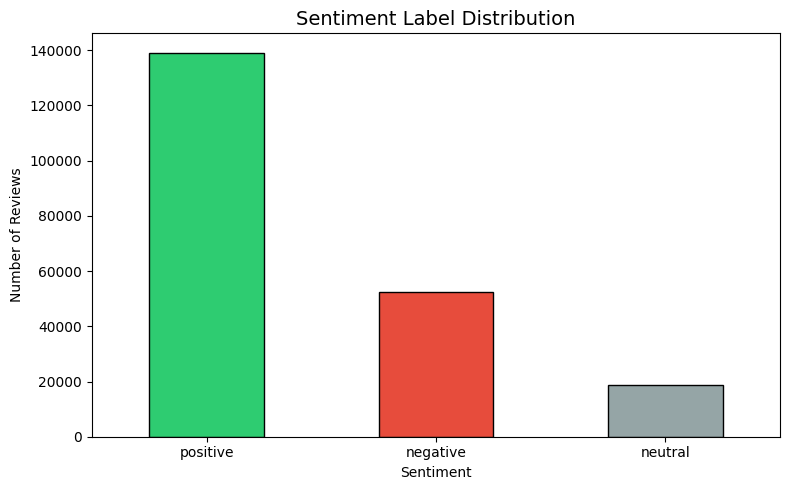

In [32]:
def assign_sentiment(rating):
    if rating <= 4:
        return 'negative'
    elif rating <= 6:
        return 'neutral'
    else:
        return 'positive'

# Apply sentiment labels
df['sentiment'] = df['rating'].apply(assign_sentiment)

# Check the distribution
print("=== SENTIMENT LABEL DISTRIBUTION ===")
print(df['sentiment'].value_counts())
print("\nPercentage breakdown:")
print((df['sentiment'].value_counts(normalize=True) * 100).round(2))

# Visualise
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', 
                                     color=['#2ecc71', '#e74c3c', '#95a5a6'],
                                     edgecolor='black')
plt.title('Sentiment Label Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sentiment labels successfully created using the following 
threshold:
- Positive: ratings 7-10 → 139,144 reviews (66.1%)
- Negative: ratings 1-4  → 52,567 reviews  (25.0%)
- Neutral:  ratings 5-6  → 18,798 reviews  (8.9%)

The distribution confirms the class imbalance anticipated 
in EDA. Positive reviews dominate at 66% which is consistent 
with the rating distribution showing ratings 9 and 10 as 
the most common values.

The neutral class is the smallest at 8.9%, consistent with 
the U-shaped rating distribution where mid-range ratings 
were least common — patients tend to review when they feel 
strongly rather than ambivalently.

Class imbalance implications for Phase 3:
The 66/25/9 split is workable but will need to be addressed 
during modelling. The pre-trained transformer model will be 
evaluated on its ability to correctly classify all three 
classes, with particular attention to neutral class 
performance given its smaller size. Class weights or 
resampling strategies will be considered if performance 
on minority classes is poor.

## Step 8 — Save Cleaned Dataset

The cleaned and labelled dataset is saved as a CSV file 
for use in Phase 3. The original train/test split column 
is preserved so the split can be reinstated for model 
evaluation without needing to re-split the data.

In [34]:
# Final check before saving
print("=== FINAL DATASET SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")

# Save to data folder
df.to_csv('data/df_clean.csv', index=False)
print("\nCleaned dataset saved to data/df_clean.csv")

=== FINAL DATASET SUMMARY ===
Shape: (210509, 11)

Columns: ['drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'split', 'review_length', 'review_clean', 'year', 'sentiment']

Data types:
drugName                    str
condition                   str
review                      str
rating                    int64
date             datetime64[us]
usefulCount               int64
split                       str
review_length             int64
review_clean                str
year                      int32
sentiment                   str
dtype: object

Sentiment distribution:
sentiment
positive    139144
negative     52567
neutral      18798
Name: count, dtype: int64

Split distribution:
split
train    157857
test      52652
Name: count, dtype: int64

Cleaned dataset saved to data/df_clean.csv
